In [1]:
import os, warnings
from pathlib import Path
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score,
)
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow :", tf.__version__)
print("GPUs found :", tf.config.list_physical_devices("GPU"))


TensorFlow : 2.20.0
GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
from google.colab import drive
import shutil
from pathlib import Path

# Mount drive
drive.mount('/content/drive')

#  PATHS
MODEL_DIR    = Path("./content/drive/MyDrive/deep-learning/DL4AI_Project_Data")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_BASE_PATH = Path('/content/drive/MyDrive/deep-learning/DL4AI_Project_Data')
LOCAL_DATA_PATH = Path('/content/data')

def setup_clean_storage(drive_path: Path, local_path: Path):
    """Copies pre-filtered clean data directly to Colab local storage."""
    if drive_path.exists():
        if not local_path.exists():
            print(f"Copying clean data from {drive_path.name} to local storage...")
            shutil.copytree(drive_path, local_path)
            print("Copy complete.")
        else:
            print(f"Data already exists at {local_path}.")
    else:
        print(f"Error: Could not find {drive_path}. Check your Drive path.")

VN_CLEAN_DRIVE     = DRIVE_BASE_PATH / "vnindex_clean"
VN_CLEAN_DIR       = LOCAL_DATA_PATH / "vietnam/vnindex_clean"

setup_clean_storage(VN_CLEAN_DRIVE, VN_CLEAN_DIR)

#  HYPER-PARAMETERS
WINDOW_SIZE  = 30
BATCH_SIZE   = 256
EPOCHS       = 30
TRAIN_FRAC   = 0.70
VAL_FRAC     = 0.15

# Forecasting horizons
K_DAY  = 7   # for Task 2.2 (predict cumulative return over 7 days)
K_DAYS = 7   # for Task 2.3 (predict each of next 7 cumulative returns)

# Auxiliary loss weight: forces direction learning
DIRECTION_LOSS_WEIGHT = 0.3


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data already exists at /content/data/vietnam/vnindex_clean.


## 1. Preprocessing

The single function `preprocess_pooled` does everything end-to-end:

1. Loads every clean CSV in `VN_CLEAN_DIR`
2. Adds technical features (RSI, MACD, Bollinger position, momentum, volatility)
3. **Computes per-ticker z-score statistics** on the training period only (no leakage)
4. **Builds windows where target = log return**, not price level
5. Returns pooled (X, y_return, y_direction, dates, tickers, last_close, ticker_means, ticker_stds)


In [19]:
# Column standardisation
_ALIASES = {
    "Date":   ["date","Date","time","Time","<DTYYYYMMDD>","<Date>","TradingDate"],
    "Open":   ["open","Open","<Open>","<OPEN>"],
    "High":   ["high","High","<High>","<HIGH>"],
    "Low":    ["low","Low","<Low>","<LOW>"],
    "Close":  ["close","Close","<Close>","<CLOSE>"],
    "Volume": ["volume","Volume","<Volume>","<VOL>"],
}

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename = {}
    for canon, aliases in _ALIASES.items():
        for a in aliases:
            if a in df.columns and canon not in rename.values():
                rename[a] = canon
                break
    return df.rename(columns=rename)


# ── Technical features (pattern features, NOT level features) ─────────────────
def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build features that encode patterns/regime, not absolute price level.

    Why this list?
    - LogRet           : the canonical stationary version of price changes
    - HL_range / OC_range: intra-day volatility & body proportion
    - SMA-ratio        : ratio of price to its moving average (trend strength,
                         scale-invariant)
    - RSI14            : momentum oscillator, naturally bounded [0,100]
    - MACD_norm        : MACD divided by price (scale-invariant version)
    - BB_pos           : position within Bollinger bands [0,1]
    - Vol_20           : rolling std of log returns (volatility regime)
    - LogVolume_z      : volume in log scale, will be z-scored later
    - Mom_5, Mom_20    : multi-timescale momentum
    """
    out = df.copy()
    p = out["Close"]

    # Returns
    out["LogRet"] = np.log(p / p.shift(1))

    # Intraday range (relative)
    out["HL_range"] = (out["High"] - out["Low"]) / out["Close"]
    out["OC_range"] = (out["Close"] - out["Open"]) / out["Open"]

    # SMA ratios (scale-invariant)
    sma5  = p.rolling(5).mean()
    sma20 = p.rolling(20).mean()
    out["SMA5_ratio"]  = p / sma5  - 1
    out["SMA20_ratio"] = p / sma20 - 1

    # MACD (normalized by price for scale invariance)
    ema12 = p.ewm(span=12, adjust=False).mean()
    ema26 = p.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    macd_sig = macd.ewm(span=9, adjust=False).mean()
    out["MACD_norm"]   = macd / p
    out["MACD_signal"] = (macd - macd_sig) / p

    # RSI-14
    delta = p.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    out["RSI14"] = (100 - 100 / (1 + rs)) / 100  # normalized to [0,1]

    # Bollinger band position
    bb_mid = p.rolling(20).mean()
    bb_std = p.rolling(20).std()
    bb_up  = bb_mid + 2 * bb_std
    bb_lo  = bb_mid - 2 * bb_std
    out["BB_pos"] = (p - bb_lo) / (bb_up - bb_lo + 1e-9)

    # Volatility (regime indicator)
    out["Vol_20"] = out["LogRet"].rolling(20).std()

    # Volume in log scale (will be z-scored)
    out["LogVolume"] = np.log1p(out["Volume"])

    # Multi-timescale momentum
    out["Mom_5"]  = p / p.shift(5)  - 1
    out["Mom_20"] = p / p.shift(20) - 1

    return out


FEATURE_COLS = [
    "LogRet", "HL_range", "OC_range",
    "SMA5_ratio", "SMA20_ratio",
    "MACD_norm", "MACD_signal",
    "RSI14", "BB_pos", "Vol_20",
    "LogVolume", "Mom_5", "Mom_20",
]


In [20]:
# Window construction with log-return targets
def build_windows_returns(
    df: pd.DataFrame,
    feature_cols: List[str],
    window_size: int,
    horizon: int,
    multi_step: bool = False,
):
    """
    Build supervised windows where target is the LOG-RETURN over `horizon` days.

    Returns
    -------
    X         : (N, window_size, n_features)
    y_return  : (N,) cumulative log return from t to t+horizon, OR
                (N, horizon) if multi_step=True (cumulative returns from t to t+1, t+2, ...)
    y_dir     : same shape as y_return; 1 if return>0 else 0 (auxiliary direction target)
    dates     : (N,) anchor date of each window (for global date split)
    last_close: (N,) the Close price at the END of the window — used to recover prices
    """
    arr_X = df[feature_cols].values.astype(np.float32)
    arr_close = df["Close"].values.astype(np.float64)
    arr_logp  = np.log(arr_close)
    arr_d = df["Date"].values
    n = len(df)

    X_list, yr_list, yd_list, d_list, lc_list = [], [], [], [], []

    for i in range(n - window_size - horizon + 1):
        end = i + window_size                # last observed index (exclusive end of window)
        last_obs_idx = end - 1               # last observed day in window
        X_list.append(arr_X[i:end])
        lc_list.append(arr_close[last_obs_idx])
        d_list.append(arr_d[i])

        if multi_step:
            # cumulative log returns from last_obs day to last_obs+1, +2, …, +horizon
            cum_rets = arr_logp[last_obs_idx + 1 : last_obs_idx + 1 + horizon] - arr_logp[last_obs_idx]
            yr_list.append(cum_rets.astype(np.float32))
            yd_list.append((cum_rets > 0).astype(np.float32))
        else:
            # single cumulative log return from last_obs day to last_obs+horizon
            r = float(arr_logp[last_obs_idx + horizon] - arr_logp[last_obs_idx])
            yr_list.append(np.float32(r))
            yd_list.append(np.float32(r > 0))

    return (
        np.stack(X_list, 0),
        np.stack(yr_list, 0),
        np.stack(yd_list, 0),
        np.array(d_list),
        np.array(lc_list, dtype=np.float64),
    )


In [22]:
# Per-ticker standardization (no leakage from val/test)
def fit_ticker_stats(
    df: pd.DataFrame,
    feature_cols: List[str],
    train_end_date: pd.Timestamp,
) -> Tuple[np.ndarray, np.ndarray]:
    """Compute mean & std using ONLY rows before train_end_date (no leakage)."""
    train_df = df[df["Date"] < train_end_date]
    if len(train_df) < 30:
        return None, None
    mu = train_df[feature_cols].mean().values.astype(np.float32)
    sd = train_df[feature_cols].std().values.astype(np.float32)
    sd = np.where(sd > 1e-8, sd, 1.0)
    return mu, sd


def apply_standardization(X: np.ndarray, mu: np.ndarray, sd: np.ndarray) -> np.ndarray:
    """Apply z-score to a (N, T, F) tensor using broadcasted (F,) stats."""
    return (X - mu[None, None, :]) / sd[None, None, :]


In [23]:
def preprocess_pooled(
    clean_dir: Path,
    horizon: int,
    multi_step: bool,
    window_size: int = WINDOW_SIZE,
    train_frac: float = TRAIN_FRAC,
    val_frac: float = VAL_FRAC,
    max_tickers: Optional[int] = None,
    verbose: bool = True,
) -> Dict:
    """
    Complete preprocessing for pooled multi-ticker training.

    Returns a dict with all train/val/test arrays plus auxiliary metadata.

    Steps
    -----
    1. Load every CSV in clean_dir
    2. Add technical features
    3. Determine global cutoff dates (train/val/test by calendar date)
    4. Per-ticker standardization fit on train period only
    5. Build windows with LOG-RETURN targets
    6. Concatenate across tickers, re-split by date
    """
    csv_files = sorted(clean_dir.glob("*.csv"))
    if max_tickers:
        csv_files = csv_files[:max_tickers]
    if verbose:
        print(f"Scanning {len(csv_files)} files…")

    # Pass 1: collect global date range
    all_dates = []
    for path in csv_files:
        try:
            # Peek at headers first so we only load the date column
            cols = pd.read_csv(path, nrows=0).columns
            date_col = next((c for c in cols if c in _ALIASES["Date"]), None)

            if date_col:
                df = pd.read_csv(path, usecols=[date_col])
                df = standardize_columns(df)
                # Convert to string first to prevent issues if dates are formatted as integers (YYYYMMDD)
                df["Date"] = pd.to_datetime(df["Date"].astype(str), errors="coerce")
                all_dates.extend(df["Date"].dropna().tolist())
        except Exception as e:
            # Print the error so we don't fail silently!
            print(f"Error reading {path.name} in Pass 1: {e}")
            continue

    sorted_dates = pd.Series(sorted(set(all_dates)))

    # Failsafe check
    if len(sorted_dates) == 0:
        raise ValueError("Critical Error: No dates could be parsed from any CSVs! Check your CSV column headers.")

    n_dates = len(sorted_dates)
    cut_train = sorted_dates.iloc[int(n_dates * train_frac)]
    cut_val   = sorted_dates.iloc[int(n_dates * (train_frac + val_frac))]

    if verbose:
        print(f"Train ends : {cut_train.date()}")
        print(f"Val   ends : {cut_val.date()}")

    # Pass 2: per-ticker windowing
    X_parts, yr_parts, yd_parts = [], [], []
    d_parts, lc_parts, t_parts  = [], [], []
    skipped = 0

    for i, path in enumerate(csv_files):
        ticker = path.stem.replace("-VNINDEX", "")
        try:
            df = pd.read_csv(path)
            df = standardize_columns(df)
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
            df = compute_features(df)
            df = df.dropna(subset=FEATURE_COLS + ["Close"]).reset_index(drop=True)
            if len(df) < window_size + horizon + 30:
                skipped += 1; continue

            # Per-ticker standardization (fit on train period only)
            mu, sd = fit_ticker_stats(df, FEATURE_COLS, cut_train)
            if mu is None:
                skipped += 1; continue

            X, yr, yd, dates, lc = build_windows_returns(
                df, FEATURE_COLS, window_size, horizon, multi_step
            )
            # Apply z-score
            X = apply_standardization(X, mu, sd)

            X_parts.append(X)
            yr_parts.append(yr)
            yd_parts.append(yd)
            d_parts.append(dates)
            lc_parts.append(lc)
            t_parts.append(np.full(len(X), ticker, dtype=object))

        except Exception as e:
            if verbose: print(f"  ⚠ {ticker}: {e}")
            skipped += 1; continue

        if verbose and (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(csv_files)} processed | "
                  f"{sum(len(a) for a in X_parts):,} windows so far")

    X_all  = np.concatenate(X_parts, 0)
    yr_all = np.concatenate(yr_parts, 0)
    yd_all = np.concatenate(yd_parts, 0)
    d_all  = np.concatenate(d_parts, 0)
    lc_all = np.concatenate(lc_parts, 0)
    t_all  = np.concatenate(t_parts, 0)

    # Date-based split
    cut_train_np = np.datetime64(cut_train)
    cut_val_np   = np.datetime64(cut_val)
    tr = d_all <  cut_train_np
    va = (d_all >= cut_train_np) & (d_all < cut_val_np)
    te = d_all >= cut_val_np

    if verbose:
        print(f"\nTotal windows      : {len(X_all):,}")
        print(f"  Train            : {tr.sum():,}")
        print(f"  Val              : {va.sum():,}")
        print(f"  Test             : {te.sum():,}")
        print(f"  Skipped tickers  : {skipped}")
        print(f"  Features         : {FEATURE_COLS}")
        print(f"  y_return mean    : {yr_all.mean():.5f}  std: {yr_all.std():.5f}")
        if not multi_step:
            print(f"  y_direction balance: {yd_all.mean():.3f} (1=up)")

    return {
        "X_train": X_all[tr], "yr_train": yr_all[tr], "yd_train": yd_all[tr],
        "X_val":   X_all[va], "yr_val":   yr_all[va], "yd_val":   yd_all[va],
        "X_test":  X_all[te], "yr_test":  yr_all[te], "yd_test":  yd_all[te],
        "lc_train": lc_all[tr], "lc_val": lc_all[va], "lc_test": lc_all[te],
        "tickers_test": t_all[te], "dates_test": d_all[te],
        "feature_cols": FEATURE_COLS,
        "horizon": horizon, "multi_step": multi_step,
    }


## 2. Model architecture

Bi-LSTM, Bi-GRU, Uni-LSTM with **two output heads**:

1. **Return head** (regression) — Huber loss; the primary output
2. **Direction head** (binary classification) — BCE loss; auxiliary signal

The direction head is the crucial innovation. By forcing the network to *also* output a probability of "price goes up," we explicitly penalize sign-wrong predictions. The total loss is:

```
total_loss  =  Huber(y_return, ŷ_return)  +  λ · BCE(y_direction, ŷ_direction)
```

with `λ = 0.3` (`DIRECTION_LOSS_WEIGHT`). This is **multi-task learning**: gradient signal from "did I get the direction right?" flows back into the shared backbone, encouraging it to learn direction-discriminative features rather than just level-fitting.

For multi-step (Task 2.3), both heads output `horizon` values — a return per future day and a direction probability per future day.


In [ ]:
def build_dual_head_lstm(
    window_size: int,
    n_features: int,
    output_size: int = 1,
) -> Model:
    """Bi-LSTM with regression + classification heads sharing a backbone."""
    inp = Input(shape=(window_size, n_features), name="input")

    x = layers.Bidirectional(layers.LSTM(96, return_sequences=True), name="bilstm_1")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.LSTM(48, return_sequences=False), name="bilstm_2")(x)
    x = layers.Dropout(0.3)(x)
    h = layers.Dense(64, activation="relu", name="shared_dense")(x)
    h = layers.Dropout(0.2)(h)

    # Two heads
    return_head    = layers.Dense(output_size, name="return_head", activation="linear")(h)
    direction_head = layers.Dense(output_size, name="direction_head", activation="sigmoid")(h)

    model = Model(inputs=inp, outputs=[return_head, direction_head], name="DualHeadLSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss={"return_head": tf.keras.losses.Huber(delta=0.02),
              "direction_head": "binary_crossentropy"},
        loss_weights={"return_head": 1.0,
                      "direction_head": DIRECTION_LOSS_WEIGHT},
        metrics={"return_head":    [tf.keras.metrics.MeanAbsoluteError(name="mae")],
                 "direction_head": ["accuracy", tf.keras.metrics.AUC(name="auc")]},
    )
    return model


CALLBACKS = [
    EarlyStopping(monitor="val_return_head_loss", mode="min",
                  patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_return_head_loss", mode="min",
                      factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

def build_dual_head_gru(
    window_size: int,
    n_features: int,
    output_size: int = 1,
) -> Model:
    """Bi-GRU with regression + classification heads sharing a backbone."""
    inp = layers.Input(shape=(window_size, n_features), name="input")

    x = layers.Bidirectional(layers.GRU(96, return_sequences=True), name="bigru_1")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(layers.GRU(48, return_sequences=False), name="bigru_2")(x)
    x = layers.Dropout(0.3)(x)
    h = layers.Dense(64, activation="relu", name="shared_dense")(x)
    h = layers.Dropout(0.2)(h)

    # Two heads
    return_head    = layers.Dense(output_size, name="return_head", activation="linear")(h)
    direction_head = layers.Dense(output_size, name="direction_head", activation="sigmoid")(h)

    model = Model(inputs=inp, outputs=[return_head, direction_head], name="DualHeadGRU")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss={"return_head": tf.keras.losses.Huber(delta=0.02),
              "direction_head": "binary_crossentropy"},
        loss_weights={"return_head": 1.0,
                      "direction_head": DIRECTION_LOSS_WEIGHT},
        metrics={"return_head":    [tf.keras.metrics.MeanAbsoluteError(name="mae")],
                 "direction_head": ["accuracy", tf.keras.metrics.AUC(name="auc")]},
    )
    return model

CALLBACKS = [
    EarlyStopping(monitor="val_return_head_loss", mode="min",
                  patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_return_head_loss", mode="min",
                      factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

In [ ]:
def build_unidirectional_lstm(
    window_size: int,
    n_features: int,
    output_size: int = 1,
) -> Model:
    """Unidirectional LSTM with regression + classification heads sharing a backbone."""
    inp = Input(shape=(window_size, n_features), name="input")

    # Backbone
    x = layers.LSTM(96, return_sequences=True, name="lstm_1")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(48, return_sequences=False, name="lstm_2")(x)
    x = layers.Dropout(0.3)(x)
    h = layers.Dense(64, activation="relu", name="shared_dense")(x)
    h = layers.Dropout(0.2)(h)

    # Two heads
    return_head    = layers.Dense(output_size, name="return_head", activation="linear")(h)
    direction_head = layers.Dense(output_size, name="direction_head", activation="sigmoid")(h)

    model = Model(inputs=inp, outputs=[return_head, direction_head], name="UnidirectionalLSTM")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
        loss={"return_head": tf.keras.losses.Huber(delta=0.02),
              "direction_head": "binary_crossentropy"},
        loss_weights={"return_head": 1.0,
                      "direction_head": DIRECTION_LOSS_WEIGHT},
        metrics={"return_head":    [tf.keras.metrics.MeanAbsoluteError(name="mae")],
                 "direction_head": ["accuracy", tf.keras.metrics.AUC(name="auc")]},
    )
    return model


CALLBACKS = [
    EarlyStopping(monitor="val_return_head_loss", mode="min",
                  patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_return_head_loss", mode="min",
                      factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

## 3. Evaluation utilities

Three layers of evaluation:

### Layer 1 — Return-level metrics (the honest ones)

- **RMSE on returns** vs **persistence baseline RMSE** (predict zero return). If our RMSE ≥ baseline, the model is worthless.
- **Directional Accuracy** on the *predicted return sign* vs realized sign.
- **Direction-head AUC** — separate signal from the auxiliary classification head.
- **Information Coefficient (IC)** — Spearman rank-correlation between predicted and actual returns. Used in quant finance; an IC > 0.05 is considered useful.

### Layer 2 — Price-level metrics (for compatibility with the project rubric)

We convert predicted return → predicted price: `P̂_{t+h} = P_t · exp(r̂)` and report MAE/RMSE/MAPE on price. These will look "good" (high R²) for the same reason as before — that's why we don't trust them in isolation.

### Layer 3 — Trading simulation

If you act on the model's predicted direction (long if up, flat otherwise), what's your hit rate and PnL? This is the most honest test for a trading-oriented project.


In [28]:
def persistence_baseline_rmse(y_return: np.ndarray) -> float:
    """RMSE of the trivial 'predict zero return' baseline."""
    return float(np.sqrt(np.mean(y_return ** 2)))


def directional_accuracy(y_true_return: np.ndarray, y_pred_return: np.ndarray) -> float:
    """Fraction of windows where sign(predicted return) == sign(true return)."""
    mask = y_true_return != 0
    if mask.sum() == 0:
        return float("nan")
    return float((np.sign(y_true_return[mask]) == np.sign(y_pred_return[mask])).mean())


def information_coefficient(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Spearman rank correlation. >0.05 is considered useful in quant finance."""
    if len(y_true) < 30:
        return float("nan")
    corr, _ = spearmanr(y_true, y_pred)
    return float(corr)


def evaluate_returns(
    y_true_return: np.ndarray,
    y_pred_return: np.ndarray,
    y_pred_direction: Optional[np.ndarray] = None,
    label: str = "",
) -> Dict[str, float]:
    """Layer 1 evaluation: return-level metrics with persistence baseline."""
    rmse_model = float(np.sqrt(mean_squared_error(y_true_return, y_pred_return)))
    rmse_base  = persistence_baseline_rmse(y_true_return)
    dir_acc    = directional_accuracy(y_true_return, y_pred_return)
    ic         = information_coefficient(y_true_return, y_pred_return)

    print(f"\n══════════ {label} — RETURN-LEVEL ══════════")
    print(f"  RMSE (model)           : {rmse_model:.6f}")
    print(f"  RMSE (persistence baseline): {rmse_base:.6f}")
    print(f"  RMSE improvement        : {(1 - rmse_model/rmse_base)*100:+.2f}%   "
          f"{'✓ beats baseline' if rmse_model < rmse_base else '✗ WORSE than predicting zero'}")
    print(f"  Directional Accuracy    : {dir_acc:.2%}   "
          f"{'✓' if dir_acc > 0.52 else '— ≈ chance'}")
    print(f"  Information Coefficient : {ic:.4f}    "
          f"{'✓ useful (>0.05)' if ic > 0.05 else '— weak'}")
    if y_pred_direction is not None:
        from sklearn.metrics import roc_auc_score
        y_dir_true = (y_true_return > 0).astype(int)
        try:
            auc = roc_auc_score(y_dir_true, y_pred_direction)
            print(f"  Direction-head AUC      : {auc:.4f}")
        except Exception:
            pass

    return {"rmse_model": rmse_model, "rmse_baseline": rmse_base,
            "dir_acc": dir_acc, "ic": ic}


def evaluate_prices(
    y_true_return: np.ndarray,
    y_pred_return: np.ndarray,
    last_close: np.ndarray,
    label: str = "",
) -> Dict[str, float]:
    """Layer 2: convert returns → prices and report standard metrics."""
    y_true_price = last_close * np.exp(y_true_return)
    y_pred_price = last_close * np.exp(y_pred_return)
    mae  = mean_absolute_error(y_true_price, y_pred_price)
    rmse = float(np.sqrt(mean_squared_error(y_true_price, y_pred_price)))
    mape = mean_absolute_percentage_error(y_true_price, y_pred_price)
    r2   = r2_score(y_true_price, y_pred_price)

    print(f"\n── {label} — PRICE-LEVEL (for rubric compatibility) ──")
    print(f"  MAE   : {mae:.4f}")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAPE  : {mape:.4%}")
    print(f"  R²    : {r2:.4f}")
    return {"mae_price": mae, "rmse_price": rmse, "mape_price": mape, "r2_price": r2}


def trading_simulation(
    y_true_return: np.ndarray,
    y_pred_return: np.ndarray,
    cost_bps: float = 20.0,
    label: str = "",
) -> Dict[str, float]:
    """Layer 3: simulate going long when predicted return > cost; report PnL."""
    cost = cost_bps / 1e4
    take_long = y_pred_return > cost
    n_trades = int(take_long.sum())
    if n_trades == 0:
        print(f"\n── Trading sim ({label}): no trades taken ──")
        return {}
    pnl = y_true_return[take_long] - cost
    win_rate = float((pnl > 0).mean())
    avg_pnl  = float(pnl.mean())
    sharpe   = float(pnl.mean() / pnl.std() * np.sqrt(252)) if pnl.std() > 0 else float("nan")
    print(f"\n── Trading sim ({label}, threshold={cost_bps}bps cost) ──")
    print(f"  N trades    : {n_trades:,} ({n_trades/len(y_true_return):.1%})")
    print(f"  Win rate    : {win_rate:.2%}")
    print(f"  Avg PnL     : {avg_pnl:+.4%}")
    print(f"  Sharpe      : {sharpe:.2f}")
    return {"n_trades": n_trades, "win_rate": win_rate,
            "avg_pnl": avg_pnl, "sharpe": sharpe}


def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["return_head_loss"],     label="train")
    axes[0].plot(history.history["val_return_head_loss"], label="val")
    axes[0].set_title(f"{title} — return loss (Huber)"); axes[0].legend(); axes[0].grid(alpha=.3)
    axes[1].plot(history.history["direction_head_auc"],     label="train")
    axes[1].plot(history.history["val_direction_head_auc"], label="val")
    axes[1].set_title(f"{title} — direction AUC"); axes[1].legend(); axes[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()


def plot_returns_scatter(y_true_return, y_pred_return, title="", n=2000):
    """Scatter of predicted vs true returns. The diagnostic plot.

    What you want to see: a cloud tilted positively up-and-to-the-right.
    A persistence-trap model would show a flat horizontal cloud near 0.
    """
    n = min(n, len(y_true_return))
    idx = np.random.choice(len(y_true_return), n, replace=False)
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true_return[idx], y_pred_return[idx], s=3, alpha=0.3)
    lim = max(abs(y_true_return[idx]).max(), abs(y_pred_return[idx]).max()) * 1.05
    plt.plot([-lim, lim], [-lim, lim], 'r--', alpha=0.5, label="perfect")
    plt.axhline(0, color='k', alpha=0.3); plt.axvline(0, color='k', alpha=0.3)
    plt.xlim(-lim, lim); plt.ylim(-lim, lim)
    plt.xlabel("True log return"); plt.ylabel("Predicted log return")
    plt.title(f"{title} — predicted vs true returns")
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()


## 2.1: Multi-feature next-day return prediction

`horizon = 1, multi_step = False` → predict next-day cumulative log return (which equals next-day log return).


In [ ]:
print("─── Preprocessing for Task 2.1 ───")
data_21 = preprocess_pooled(
    VN_CLEAN_DIR, horizon=1, multi_step=False,
    window_size=WINDOW_SIZE,
)

─── Preprocessing for Task 2.1 ───
Scanning 348 files…
Train ends : 2016-08-30
Val   ends : 2019-11-26
  100/348 processed | 257,918 windows so far
  200/348 processed | 510,912 windows so far
  300/348 processed | 784,287 windows so far

Total windows      : 897,502
  Train            : 467,236
  Val              : 223,049
  Test             : 207,217
  Skipped tickers  : 70
  Features         : ['LogRet', 'HL_range', 'OC_range', 'SMA5_ratio', 'SMA20_ratio', 'MACD_norm', 'MACD_signal', 'RSI14', 'BB_pos', 'Vol_20', 'LogVolume', 'Mom_5', 'Mom_20']
  y_return mean    : 0.00021  std: 0.02778
  y_direction balance: 0.387 (1=up)


In [ ]:
print("─── Building model for Task 2.1 with LSTM───")
model_21_lstm = build_unidirectional_lstm(
    window_size=WINDOW_SIZE,
    n_features=len(data_21["feature_cols"]),
    output_size=1,
)
model_21_lstm.summary()

─── Building model for Task 2.1 with LSTM───


Model: "UnidirectionalLSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 13)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 60, 96)    │     42,240 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 60, 96)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 48)        │     27,840 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 48)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense        │ (None, 64)        │      3,136 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ shared_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ return_head (Dense) │ (None, 1)         │         65 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ direction_head      │ (None, 1)         │         65 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 73,346 (286.51 KB)

 Trainable params: 73,346 (286.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("─── Training Task 2.1 ───")
history_21_lstm = model_21_lstm.fit(
    data_21["X_train"],
    {"return_head":    data_21["yr_train"],
     "direction_head": data_21["yd_train"]},
    validation_data=(
        data_21["X_val"],
        {"return_head":    data_21["yr_val"],
         "direction_head": data_21["yd_val"]},
    ),
    epochs=30, batch_size=BATCH_SIZE,
    callbacks=CALLBACKS, verbose=2,
)

print("\n")

─── Training Task 2.1 ───
Epoch 1/30
1826/1826 - 40s - 22ms/step - direction_head_accuracy: 0.6284 - direction_head_auc: 0.5830 - direction_head_loss: 0.6507 - loss: 0.1956 - return_head_loss: 3.6060e-04 - return_head_mae: 0.0257 - val_direction_head_accuracy: 0.6304 - val_direction_head_auc: 0.6115 - val_direction_head_loss: 0.6471 - val_loss: 0.1943 - val_return_head_loss: 2.1031e-04 - val_return_head_mae: 0.0168 - learning_rate: 5.0000e-04
Epoch 2/30
1826/1826 - 36s - 20ms/step - direction_head_accuracy: 0.6395 - direction_head_auc: 0.6154 - direction_head_loss: 0.6402 - loss: 0.1923 - return_head_loss: 2.4986e-04 - return_head_mae: 0.0195 - val_direction_head_accuracy: 0.6342 - val_direction_head_auc: 0.6173 - val_direction_head_loss: 0.6448 - val_loss: 0.1937 - val_return_head_loss: 2.0872e-04 - val_return_head_mae: 0.0167 - learning_rate: 5.0000e-04
Epoch 3/30
1826/1826 - 31s - 17ms/step - direction_head_accuracy: 0.6431 - direction_head_auc: 0.6238 - direction_head_loss: 0.6365 

NameError: name 'plot_history' is not defined

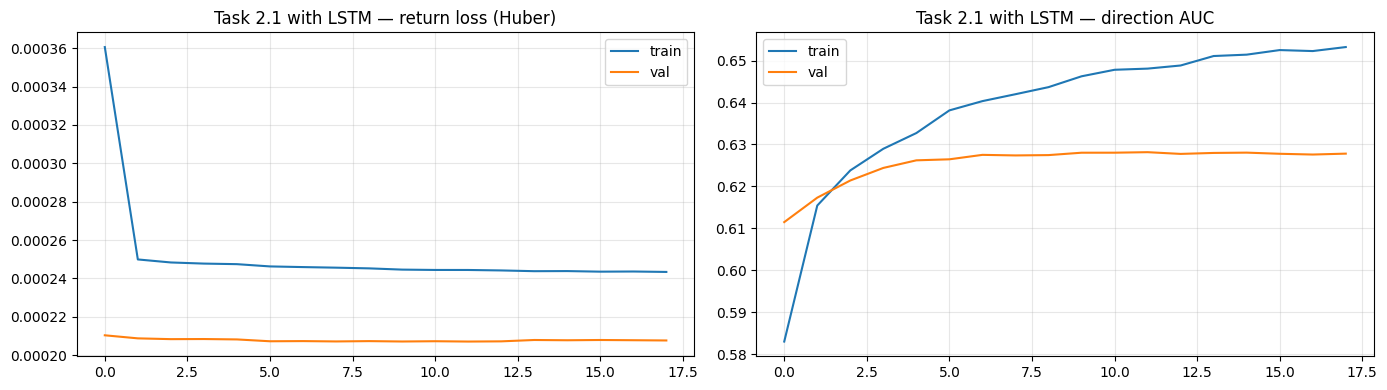

In [ ]:
plot_history(history_21_lstm, "Task 2.1 with LSTM")

In [ ]:
from google.colab import drive
from pathlib import Path

# 1. Mount your Google Drive
# This will prompt you to authorize access if you haven't already
drive.mount('/content/drive')

# 2. Define MODEL_DIR to point to a specific folder IN YOUR DRIVE
# Replace 'My Project Folder' with the actual folder name you want to use in Drive
MODEL_DIR = Path('/content/drive/MyDrive/My Project Folder')

print("Saving model for Task 2.1...")

# 3. Save the model (your existing code)
model_save_path = MODEL_DIR / "models" / "model_21_lstm.keras"
model_save_path.parent.mkdir(parents=True, exist_ok=True)
model_21_lstm.save(model_save_path)

print(f"Model saved to: {model_save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving model for Task 2.1...
Model saved to: /content/drive/MyDrive/My Project Folder/models/model_21_lstm.keras


In [ ]:
print("─── Evaluating Task 2.1 ───")
preds_21 = model_21_lstm.predict(data_21["X_test"], batch_size=BATCH_SIZE, verbose=0)
y_pred_return_21    = preds_21[0].flatten()
y_pred_direction_21 = preds_21[1].flatten()

evaluate_returns(data_21["yr_test"], y_pred_return_21,
                 y_pred_direction=y_pred_direction_21,
                 label="Task 2.1 — next-day")

evaluate_prices(data_21["yr_test"], y_pred_return_21,
                data_21["lc_test"], label="Task 2.1")

trading_simulation(data_21["yr_test"], y_pred_return_21,
                   cost_bps=20.0, label="Task 2.1")

─── Evaluating Task 2.1 ───

══════════ Task 2.1 — next-day — RETURN-LEVEL ══════════
  RMSE (model)           : 0.030353
  RMSE (persistence baseline): 0.030686
  RMSE improvement        : +1.08%   ✓ beats baseline
  Directional Accuracy    : 55.17%   ✓
  Information Coefficient : 0.1362    ✓ useful (>0.05)
  Direction-head AUC      : 0.6037

── Task 2.1 — PRICE-LEVEL (for rubric compatibility) ──
  MAE   : 455.1623
  RMSE  : 874.7453
  MAPE  : 2.1068%
  R²    : 0.9986

── Trading sim (Task 2.1, threshold=20.0bps cost) ──
  N trades    : 51,876 (25.0%)
  Win rate    : 51.31%
  Avg PnL     : +0.3663%
  Sharpe      : 1.55


{'n_trades': 51876,
 'win_rate': 0.5131467345207803,
 'avg_pnl': 0.003662859322503209,
 'sharpe': 1.5499150418033858}

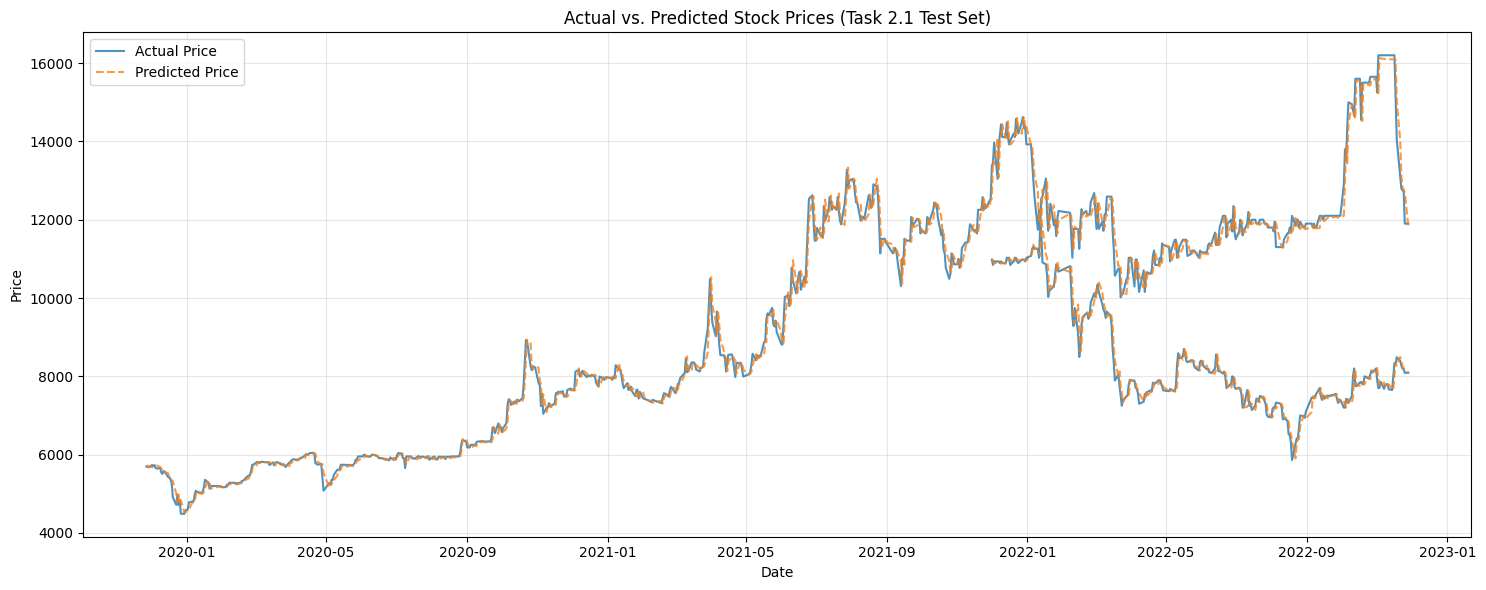

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convert returns to prices for the test set
y_true_price_21 = data_21["lc_test"] * np.exp(data_21["yr_test"])
y_pred_price_21 = data_21["lc_test"] * np.exp(y_pred_return_21)
dates_test_21 = pd.to_datetime(data_21["dates_test"])

# Select a subset for plotting (e.g., the last N points to show a continuous period)
N_PLOT = 1000

if len(dates_test_21) > N_PLOT:
    start_idx = len(dates_test_21) - N_PLOT
    plot_dates = dates_test_21[start_idx:]
    plot_true_price = y_true_price_21[start_idx:]
    plot_pred_price = y_pred_price_21[start_idx:]
else:
    plot_dates = dates_test_21
    plot_true_price = y_true_price_21
    plot_pred_price = y_pred_price_21

is_new_ticker = np.concatenate([[False], plot_dates.values[1:] < plot_dates.values[:-1]])

plot_true_price = np.where(is_new_ticker, np.nan, plot_true_price)
plot_pred_price = np.where(is_new_ticker, np.nan, plot_pred_price)

plt.figure(figsize=(15, 6))
plt.plot(plot_dates, plot_true_price, label='Actual Price', alpha=0.8)
plt.plot(plot_dates, plot_pred_price, label='Predicted Price', alpha=0.8, linestyle='--')
plt.title('Actual vs. Predicted Stock Prices (Task 2.1 Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.2: k-th day forecast

Predict the **cumulative log return** from t to t+K_DAY (single output). The model must look further into the future, which is fundamentally harder. We expect:
- RMSE-vs-baseline gap to narrow as horizon grows (entropy increases)
- Direction accuracy ~50–55% (further out is harder)
- IC may still be positive — trends do persist over short horizons


In [24]:
print(f"─── Preprocessing for Task 2.2 (horizon = {K_DAY}) ───")
data_22 = preprocess_pooled(
    VN_CLEAN_DIR, horizon=K_DAY, multi_step=False,
    window_size=WINDOW_SIZE,
)


─── Preprocessing for Task 2.2 (horizon = 7) ───
Scanning 348 files…
Train ends : 2016-08-30
Val   ends : 2019-11-26
  100/348 processed | 259,934 windows so far
  200/348 processed | 514,776 windows so far
  300/348 processed | 790,095 windows so far

Total windows      : 904,174
  Train            : 467,236
  Val              : 223,049
  Test             : 213,889
  Skipped tickers  : 70
  Features         : ['LogRet', 'HL_range', 'OC_range', 'SMA5_ratio', 'SMA20_ratio', 'MACD_norm', 'MACD_signal', 'RSI14', 'BB_pos', 'Vol_20', 'LogVolume', 'Mom_5', 'Mom_20']
  y_return mean    : 0.00141  std: 0.07665
  y_direction balance: 0.464 (1=up)


─── Preprocessing for Task 2.2 (horizon = 7) ───
Scanning 348 files…
Train ends : 2016-08-30
Val   ends : 2019-11-26
  100/348 processed | 259,934 windows so far
  200/348 processed | 514,776 windows so far
  300/348 processed | 790,095 windows so far

Total windows      : 904,174
  Train            : 467,236
  Val              : 223,049
  Test             : 213,889
  Skipped tickers  : 70
  Features         : ['LogRet', 'HL_range', 'OC_range', 'SMA5_ratio', 'SMA20_ratio', 'MACD_norm', 'MACD_signal', 'RSI14', 'BB_pos', 'Vol_20', 'LogVolume', 'Mom_5', 'Mom_20']
  y_return mean    : 0.00141  std: 0.07665
  y_direction balance: 0.464 (1=up)
─── Training Task 2.2 (k = 7) ───
Epoch 1/30
1826/1826 - 46s - 25ms/step - direction_head_accuracy: 0.5685 - direction_head_auc: 0.5814 - direction_head_loss: 0.6775 - loss: 0.2043 - return_head_loss: 0.0010 - return_head_mae: 0.0591 - val_direction_head_accuracy: 0.5574 - val_direction_head_auc: 0.5636 - val_direction_head_loss: 0.6836 - val_loss: 0.2

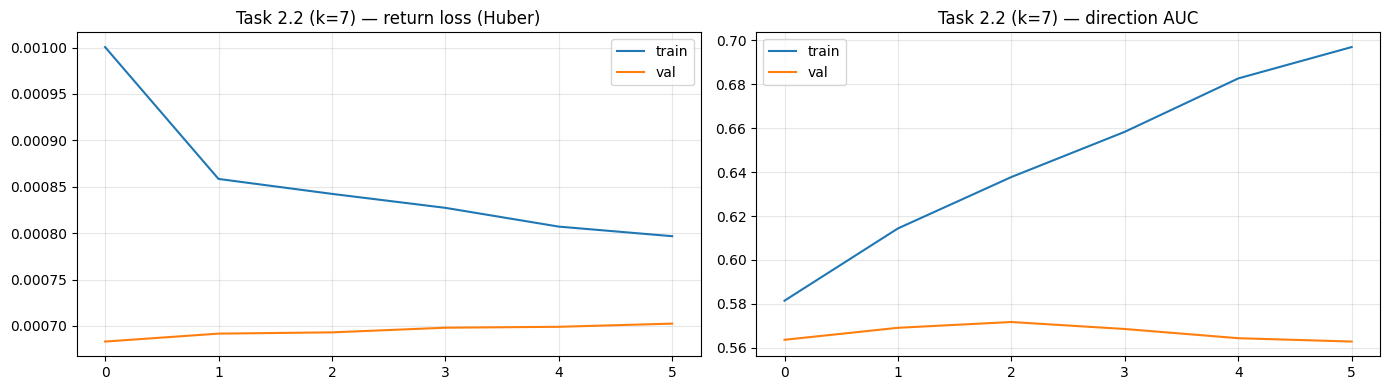

In [ ]:
model_22 = build_dual_head_lstm(
    window_size=WINDOW_SIZE,
    n_features=len(data_22["feature_cols"]),
    output_size=1,
)

print(f"\n─── Training Task 2.2 (k = {K_DAY}) ───")
history_22 = model_22.fit(
    data_22["X_train"],
    {"return_head":    data_22["yr_train"],
     "direction_head": data_22["yd_train"]},
    validation_data=(
        data_22["X_val"],
        {"return_head":    data_22["yr_val"],
         "direction_head": data_22["yd_val"]},
    ),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=CALLBACKS, verbose=2,
)

print("\n")
plot_history(history_22, f"Task 2.2 (k={K_DAY})")


In [29]:
print(f"─── Evaluating Task 2.2 (k = {K_DAY}) ───")
preds_22 = model_22.predict(data_22["X_test"], batch_size=BATCH_SIZE, verbose=0)
y_pred_return_22    = preds_22[0].flatten()
y_pred_direction_22 = preds_22[1].flatten()

evaluate_returns(data_22["yr_test"], y_pred_return_22,
                 y_pred_direction=y_pred_direction_22,
                 label=f"Task 2.2 — t+{K_DAY}")

evaluate_prices(data_22["yr_test"], y_pred_return_22,
                data_22["lc_test"], label=f"Task 2.2 — t+{K_DAY}")

trading_simulation(data_22["yr_test"], y_pred_return_22,
                   cost_bps=20.0, label=f"Task 2.2 t+{K_DAY}")


─── Evaluating Task 2.2 (k = 7) ───

══════════ Task 2.2 — t+7 — RETURN-LEVEL ══════════
  RMSE (model)           : 0.088852
  RMSE (persistence baseline): 0.087612
  RMSE improvement        : -1.42%   ✗ WORSE than predicting zero
  Directional Accuracy    : 51.55%   — ≈ chance
  Information Coefficient : 0.0377    — weak
  Direction-head AUC      : 0.5280

── Task 2.2 — t+7 — PRICE-LEVEL (for rubric compatibility) ──
  MAE   : 1275.6309
  RMSE  : 2290.0966
  MAPE  : 6.0592%
  R²    : 0.9904

── Trading sim (Task 2.2 t+7, threshold=20.0bps cost) ──
  N trades    : 73,627 (34.4%)
  Win rate    : 51.74%
  Avg PnL     : +0.3912%
  Sharpe      : 0.69


{'n_trades': 73627,
 'win_rate': 0.5173781357382482,
 'avg_pnl': 0.003911829087883234,
 'sharpe': 0.6903109105294016}

In [ ]:
from google.colab import drive
from pathlib import Path

# 1. Mount your Google Drive
# This will prompt you to authorize access if you haven't already
drive.mount('/content/drive')

# 2. Define MODEL_DIR to point to a specific folder IN YOUR DRIVE
# Replace 'My Project Folder' with the actual folder name you want to use in Drive
MODEL_DIR = Path('/content/drive/MyDrive/My Project Folder')

print("Saving model for Task 2.2...")

# 3. Save the model (your existing code)
model_save_path = MODEL_DIR / "models" / "model_22.keras"
model_save_path.parent.mkdir(parents=True, exist_ok=True)
model_22.save(model_save_path)

print(f"Model saved to: {model_save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving model for Task 2.2...
Model saved to: /content/drive/MyDrive/My Project Folder/models/model_22.keras


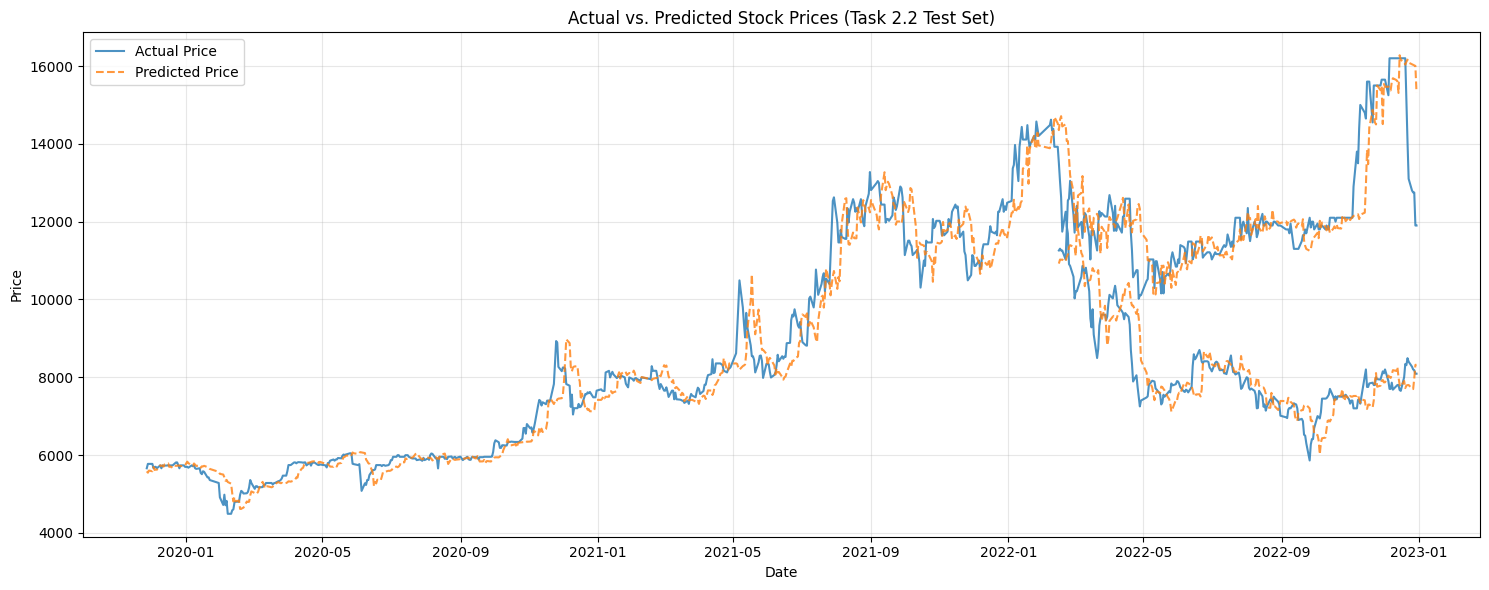

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Convert returns to prices for the test set
y_true_price_22 = data_22["lc_test"] * np.exp(data_22["yr_test"])
y_pred_price_22 = data_22["lc_test"] * np.exp(y_pred_return_22)
dates_test_22 = pd.to_datetime(data_22["dates_test"])

# Select a subset for plotting (e.g., the last N points to show a continuous period)
N_PLOT = 1000

if len(dates_test_22) > N_PLOT:
    start_idx = len(dates_test_22) - N_PLOT
    plot_dates = dates_test_22[start_idx:]
    plot_true_price = y_true_price_22[start_idx:]
    plot_pred_price = y_pred_price_22[start_idx:]
else:
    plot_dates = dates_test_22
    plot_true_price = y_true_price_22
    plot_pred_price = y_pred_price_22

is_new_ticker = np.concatenate([[False], plot_dates.values[1:] < plot_dates.values[:-1]])

plot_true_price = np.where(is_new_ticker, np.nan, plot_true_price)
plot_pred_price = np.where(is_new_ticker, np.nan, plot_pred_price)

plt.figure(figsize=(15, 6))
plt.plot(plot_dates, plot_true_price, label='Actual Price', alpha=0.8)
plt.plot(plot_dates, plot_pred_price, label='Predicted Price', alpha=0.8, linestyle='--')
plt.title('Actual vs. Predicted Stock Prices (Task 2.2 Test Set)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3: k-consecutive days forecast

Predict cumulative log returns to each of t+1, t+2, …, t+K_DAYS jointly. Both heads emit `K_DAYS` values.


In [34]:
print(f"─── Preprocessing for Task 2.3 (horizon = {K_DAYS}) ───")
data_23 = preprocess_pooled(
    VN_CLEAN_DIR, horizon=K_DAYS, multi_step=True,
    window_size=WINDOW_SIZE,
)


─── Preprocessing for Task 2.3 (horizon = 7) ───
Scanning 348 files…
Train ends : 2016-08-30
Val   ends : 2019-11-26
  100/348 processed | 259,934 windows so far
  200/348 processed | 514,776 windows so far
  300/348 processed | 790,095 windows so far

Total windows      : 904,174
  Train            : 467,236
  Val              : 223,049
  Test             : 213,889
  Skipped tickers  : 70
  Features         : ['LogRet', 'HL_range', 'OC_range', 'SMA5_ratio', 'SMA20_ratio', 'MACD_norm', 'MACD_signal', 'RSI14', 'BB_pos', 'Vol_20', 'LogVolume', 'Mom_5', 'Mom_20']
  y_return mean    : 0.00082  std: 0.05758


─── Preprocessing for Task 2.3 (horizon = 7) ───
Scanning 348 files…
Train ends : 2016-08-30
Val   ends : 2019-11-26
  100/348 processed | 259,934 windows so far
  200/348 processed | 514,776 windows so far
  300/348 processed | 790,095 windows so far

Total windows      : 904,174
  Train            : 467,236
  Val              : 223,049
  Test             : 213,889
  Skipped tickers  : 70
  Features         : ['LogRet', 'HL_range', 'OC_range', 'SMA5_ratio', 'SMA20_ratio', 'MACD_norm', 'MACD_signal', 'RSI14', 'BB_pos', 'Vol_20', 'LogVolume', 'Mom_5', 'Mom_20']
  y_return mean    : 0.00082  std: 0.05758
─── Training Task 2.3 (7 consecutive days) ───
Epoch 1/30
1826/1826 - 53s - 29ms/step - direction_head_accuracy: 0.0478 - direction_head_auc: 0.5887 - direction_head_loss: 0.6696 - loss: 0.2016 - return_head_loss: 7.5445e-04 - return_head_mae: 0.0464 - val_direction_head_accuracy: 0.0442 - val_direction_head_auc: 0.5875 - val_direction_head_loss: 0.6714 - val_loss: 0.2019 - val_return_he

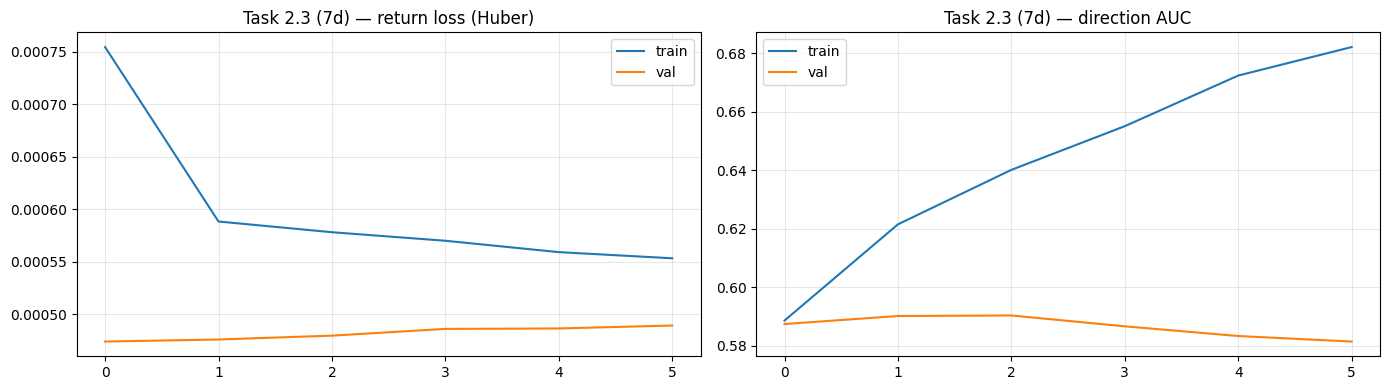

In [ ]:
model_23 = build_dual_head_lstm(
    window_size=WINDOW_SIZE,
    n_features=len(data_23["feature_cols"]),
    output_size=K_DAYS,
)

print(f"─── Training Task 2.3 ({K_DAYS} consecutive days) ───")
history_23 = model_23.fit(
    data_23["X_train"],
    {"return_head":    data_23["yr_train"],
     "direction_head": data_23["yd_train"]},
    validation_data=(
        data_23["X_val"],
        {"return_head":    data_23["yr_val"],
         "direction_head": data_23["yd_val"]},
    ),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=CALLBACKS, verbose=2,
)
plot_history(history_23, f"Task 2.3 ({K_DAYS}d)")


─── Evaluating Task 2.3 (per-horizon) ───

══════════ Task 2.3 per-horizon ══════════
    h        rmse    baseline     gain    DirAcc       IC  price_MAPE
  t+1      0.03056     0.03065    +0.3%   53.42%   0.0988      2.13%
  t+2      0.04520     0.04520    +0.0%   53.10%   0.0889      3.11%
  t+3      0.05636     0.05616    -0.4%   52.52%   0.0834      3.87%
  t+4      0.06582     0.06531    -0.8%   52.70%   0.0682      4.49%
  t+5      0.07393     0.07344    -0.7%   52.73%   0.0655      5.04%
  t+6      0.08140     0.08088    -0.6%   52.57%   0.0632      5.55%
  t+7      0.08854     0.08761    -1.1%   52.14%   0.0578      6.03%


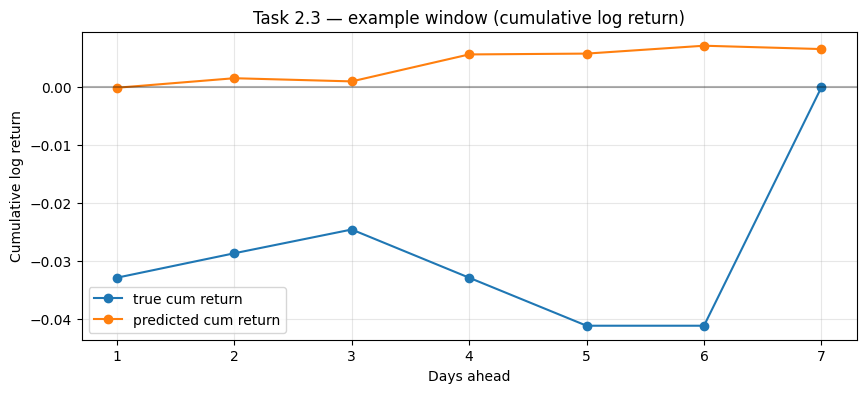

In [36]:
print(f"─── Evaluating Task 2.3 (per-horizon) ───")
preds_23 = model_23.predict(data_23["X_test"], batch_size=BATCH_SIZE, verbose=0)
y_pred_return_23    = preds_23[0]      # (N, K_DAYS)
y_pred_direction_23 = preds_23[1]      # (N, K_DAYS)

# Per-horizon metrics — return & price level
print("\n══════════ Task 2.3 per-horizon ══════════")
print(f"  {'h':>3}  {'rmse':>10}  {'baseline':>10}  {'gain':>7}  "
      f"{'DirAcc':>8}  {'IC':>7}  {'price_MAPE':>10}")
for k in range(K_DAYS):
    yt = data_23["yr_test"][:, k]
    yp = y_pred_return_23[:, k]
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    base = persistence_baseline_rmse(yt)
    da   = directional_accuracy(yt, yp)
    ic   = information_coefficient(yt, yp)
    yt_p = data_23["lc_test"] * np.exp(yt)
    yp_p = data_23["lc_test"] * np.exp(yp)
    mape = mean_absolute_percentage_error(yt_p, yp_p)
    print(f"  t+{k+1:<2}  {rmse:>10.5f}  {base:>10.5f}  "
          f"{(1-rmse/base)*100:>+6.1f}%  {da:>7.2%}  {ic:>7.4f}  {mape:>9.2%}")

# Visualize one example trajectory
plt.figure(figsize=(10, 4))
plt.plot(range(1, K_DAYS+1), data_23["yr_test"][0],  marker='o', label='true cum return')
plt.plot(range(1, K_DAYS+1), y_pred_return_23[0],   marker='o', label='predicted cum return')
plt.title(f"Task 2.3 — example window (cumulative log return)")
plt.xlabel("Days ahead"); plt.ylabel("Cumulative log return")
plt.axhline(0, color='k', alpha=0.3); plt.legend(); plt.grid(alpha=.3); plt.show()


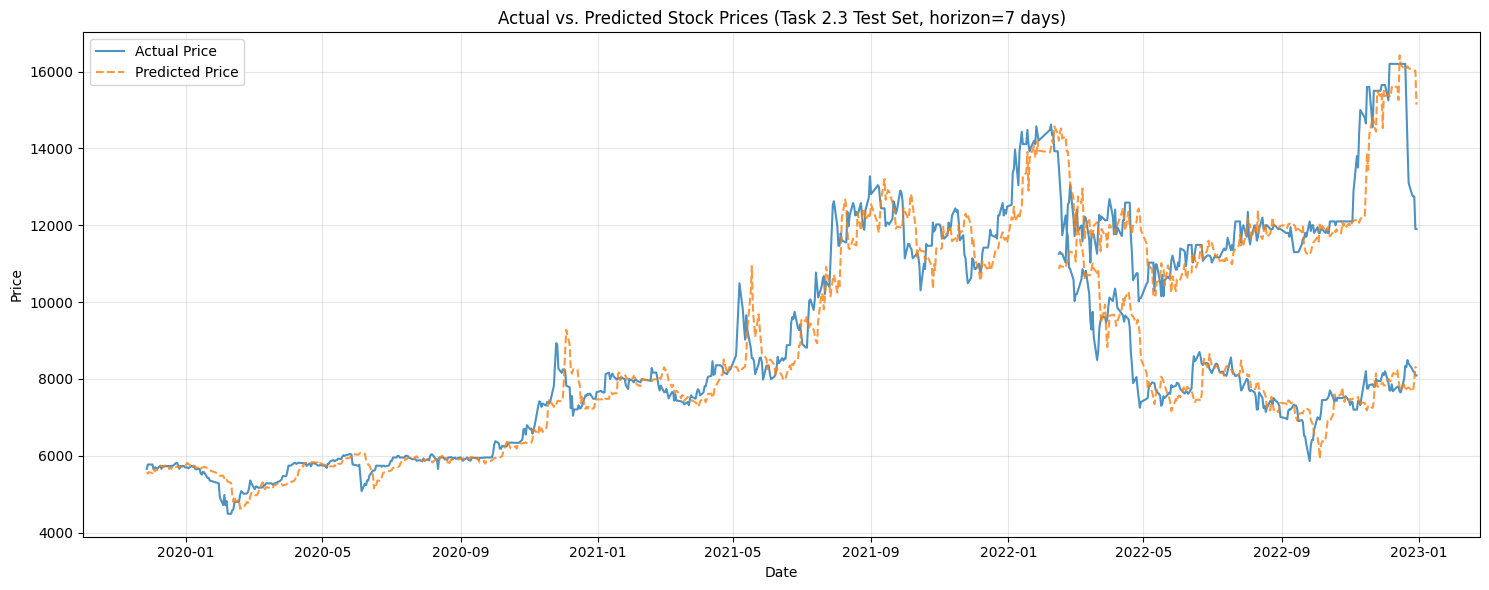

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

y_true_price_23 = data_23["lc_test"] * np.exp(data_23["yr_test"][:, K_DAY-1])
y_pred_price_23 = data_23["lc_test"] * np.exp(y_pred_return_23[:, K_DAY-1])
dates_test_23 = pd.to_datetime(data_23["dates_test"])

# Select a subset for plotting (e.g., the last N points to show a continuous period)
N_PLOT_23 = 1000 # You can adjust this number

if len(dates_test_23) > N_PLOT_23:
    start_idx_23 = len(dates_test_23) - N_PLOT_23
    plot_dates_23 = dates_test_23[start_idx_23:]
    plot_true_price_23 = y_true_price_23[start_idx_23:]
    plot_pred_price_23 = y_pred_price_23[start_idx_23:]
else:
    plot_dates_23 = dates_test_23
    plot_true_price_23 = y_true_price_23
    plot_pred_price_23 = y_pred_price_23

is_new_ticker = np.concatenate([[False], plot_dates_23.values[1:] < plot_dates_23.values[:-1]])

plot_true_price_23 = np.where(is_new_ticker, np.nan, plot_true_price_23)
plot_pred_price_23 = np.where(is_new_ticker, np.nan, plot_pred_price_23)

plt.figure(figsize=(15, 6))
plt.plot(plot_dates_23, plot_true_price_23, label='Actual Price', alpha=0.8)
plt.plot(plot_dates_23, plot_pred_price_23, label='Predicted Price', alpha=0.8, linestyle='--')
plt.title(f'Actual vs. Predicted Stock Prices (Task 2.3 Test Set, horizon={K_DAY} days)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Save model to drive

MODEL_DIR = Path('/content/drive/MyDrive/My Project Folder')

print("Saving model for Task 2.3...")

model_save_path = MODEL_DIR / "models" / "model_23.keras"
model_save_path.parent.mkdir(parents=True, exist_ok=True)
model_23.save(model_save_path)

print(f"Model saved to: {model_save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving model for Task 2.3...
Model saved to: /content/drive/MyDrive/My Project Folder/models/model_23.keras
